<a href="https://colab.research.google.com/github/capstonn/capstonn.github.io/blob/main/mnist_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
root_dir = '/content/drive/MyDrive/pytorch_test/mnist/'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

In [ ]:
is_cuda = torch.cuda.is_available()
is_cuda

True

In [ ]:
device = torch.device('cuda' if is_cuda else 'cpu')
device

device(type='cuda')

In [ ]:

batch_size = 50
epoch_num = 15
learning_rate = 0.0001

In [ ]:
train_data = datasets.MNIST(root=root_dir+'/data',
                            train=True,
                            download = True,
                            transform=transforms.ToTensor())
test_data = datasets.MNIST(root=root_dir+'/data',
                            train=False,
                            transform=transforms.ToTensor())

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 49969965.94it/s]


Extracting /content/drive/MyDrive/Colab Notebooks/pytorch_test/mnist/data/MNIST/raw/train-images-idx3-ubyte.gz to /content/drive/MyDrive/Colab Notebooks/pytorch_test/mnist/data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 2468580.09it/s]

Extracting /content/drive/MyDrive/Colab Notebooks/pytorch_test/mnist/data/MNIST/raw/train-labels-idx1-ubyte.gz to /content/drive/MyDrive/Colab Notebooks/pytorch_test/mnist/data/MNIST/raw



Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 13918887.19it/s]


Extracting /content/drive/MyDrive/Colab Notebooks/pytorch_test/mnist/data/MNIST/raw/t10k-images-idx3-ubyte.gz to /content/drive/MyDrive/Colab Notebooks/pytorch_test/mnist/data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 5327329.07it/s]


Extracting /content/drive/MyDrive/Colab Notebooks/pytorch_test/mnist/data/MNIST/raw/t10k-labels-idx1-ubyte.gz to /content/drive/MyDrive/Colab Notebooks/pytorch_test/mnist/data/MNIST/raw



In [ ]:
len(train_data),len(test_data)

(60000, 10000)

In [ ]:
type(train_data)

torchvision.datasets.mnist.MNIST

In [ ]:
len(train_data[0])

2

In [ ]:
image,label = train_data[0]

In [ ]:
label

5

In [ ]:
image.shape

torch.Size([1, 28, 28])

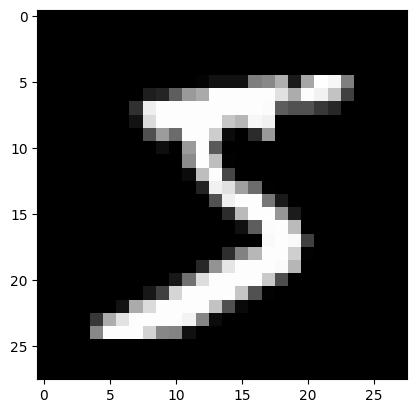

In [ ]:
plt.imshow(image.squeeze(),cmap='gray')

In [ ]:
train_loader = torch.utils.data.DataLoader(dataset=train_data,
                                           batch_size=batch_size,
                                           shuffle = True)
test_loader = torch.utils.data.DataLoader(dataset=test_data,
                                           batch_size=batch_size,
                                           shuffle = True)

In [ ]:
first_batch = train_loader.__iter__().__next__()

In [ ]:
type(first_batch)

list

In [ ]:
len(first_batch)

2

In [ ]:
first_batch[0].shape

torch.Size([50, 1, 28, 28])

In [ ]:
first_batch[1].shape

torch.Size([50])

In [ ]:
print(f"{'name':15s} | {'type':<25s} | {'size'}")
print(f"{'num of batch':15s} | {'':<25s} | {len(train_loader)}")
print(f"{'first_batch':15s} | {str(type(first_batch)):<25s} | {len(first_batch)}")
print(f"{'first_batch[0]':15s} | {str(type(first_batch[0])):<25s} | {first_batch[0].shape}")
print(f"{'first_batch[1]':15s} | {str(type(first_batch[1])):<25s} | {first_batch[1].shape}")

name            | type                      | size
num of batch    |                           | 1200
first_batch     | <class 'list'>            | 2
first_batch[0]  | <class 'torch.Tensor'>    | torch.Size([50, 1, 28, 28])
first_batch[1]  | <class 'torch.Tensor'>    | torch.Size([50])


In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout2d(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

In [ ]:
model = CNN().to(device)
optimizer = optim.Adam(model.parameters(),lr = learning_rate)
criterion = nn.CrossEntropyLoss()

In [ ]:
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (dropout2): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
model.train()
i = 0
for epoch in range(epoch_num):
  for data, target in train_loader:
    data = data.to(device)
    target = target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output,target)
    loss.backward()
    optimizer.step()
    if i % 1000 == 0:
      print(f"train step:{i}\tloss:{loss.item()}")
    i += 1


/usr/local/lib/python3.10/dist-packages/torch/nn/functional.py:1374: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


train step:0	loss:2.3234903812408447
train step:1000	loss:0.33015117049217224
train step:2000	loss:0.0926746279001236
train step:3000	loss:0.19567358493804932
train step:4000	loss:0.21745073795318604
train step:5000	loss:0.15488384664058685
train step:6000	loss:0.0841209664940834
train step:7000	loss:0.005607808008790016
train step:8000	loss:0.03845977783203125
train step:9000	loss:0.056115008890628815
train step:10000	loss:0.0173705592751503
train step:11000	loss:0.02384316176176071
train step:12000	loss:0.08663830906152725
train step:13000	loss:0.0997326597571373
train step:14000	loss:0.027421901002526283
train step:15000	loss:0.07344522327184677
train step:16000	loss:0.007844647392630577
train step:17000	loss:0.07772964239120483


In [ ]:
model.eval()
correct = 0
for data, target in test_loader:
  data = data.to(device)
  target = target.to(device)
  output = model(data)
  prediction = output.data.max(1)[1]
  correct += prediction.eq(target.data).sum()

In [ ]:
output.shape

torch.Size([50, 10])

In [ ]:
output.data.max(1)

torch.return_types.max(
values=tensor([-6.4364e-02, -2.0504e-05, -4.8399e-04, -1.3113e-06, -3.5763e-07,
        -1.5497e-06, -1.8521e-03, -3.6716e-05, -6.9497e-05, -8.9407e-06,
        -1.0967e-05, -5.5550e-05, -1.9550e-05, -8.2398e-02, -1.0729e-06,
        -1.2099e-04, -4.7554e-01,  0.0000e+00, -3.4212e-05, -2.3842e-07,
        -9.6559e-06, -5.1124e-03, -1.7881e-06, -5.9605e-07, -7.5102e-06,
         0.0000e+00, -1.5222e-04, -1.1921e-07, -3.3410e-03, -4.4702e-05,
        -1.7881e-05, -2.8610e-06, -8.8214e-06, -1.6569e-04, -2.3842e-07,
        -3.1067e-03, -1.0729e-06, -6.4967e-05, -1.8483e-01, -1.1921e-07,
        -6.9096e-03, -1.2398e-05, -8.8214e-06, -2.2426e-03, -3.5763e-07,
        -1.3113e-06, -2.3842e-07, -1.4305e-06, -1.1061e-03, -1.1921e-07],
       device='cuda:0'),
indices=tensor([5, 3, 1, 0, 5, 4, 2, 5, 1, 7, 8, 1, 1, 8, 0, 6, 9, 4, 6, 8, 7, 8, 8, 9,
        2, 3, 1, 6, 9, 7, 0, 0, 7, 2, 3, 2, 9, 1, 3, 6, 7, 5, 6, 5, 7, 7, 0, 5,
        9, 5], device='cuda:0'))

In [ ]:
100*correct/len(test_loader.dataset)

tensor(98.9700, device='cuda:0')

In [ ]:
torch.save(model.state_dict(),root_dir+'/mnist_model.pth')

In [ ]:
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF
import torch

In [ ]:
root_dir = '/content/drive/MyDrive/pytorch_test/mnist/'

In [ ]:
def preprocess_image(img_path):
    print(img_path)
    image = Image.open(img_path)
    if image.mode == 'RGBA':
        image = image.convert('L')
    preprocess = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((28,28)),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,),(0.3081,))

    ])
    image = TF.invert(image)
    image_tensor = preprocess(image).unsqueeze(0)

    return image_tensor


In [ ]:
image_tensor = preprocess_image(root_dir + '/data/myimg/3.png')

/content/drive/MyDrive/pytorch_test/mnist//data/myimg/3.png


In [ ]:
image_tensor.shape

torch.Size([1, 1, 28, 28])

In [ ]:
model = CNN()
model.load_state_dict(torch.load(root_dir+'/mnist_model.pth', weights_only= True))
model.eval()
with torch.no_grad():
    output = model(image_tensor)
    predicted = torch.argmax(output, dim = 1)
    print(output)
    print(predicted.item())

tensor([[-2.2460, -2.2663, -2.3432, -2.4370, -2.4228, -2.3037, -2.3355, -2.2605,
         -2.2755, -2.1656]])
9


/usr/local/lib/python3.10/dist-packages/torch/nn/functional.py:1374: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


torch.Size([28, 28])


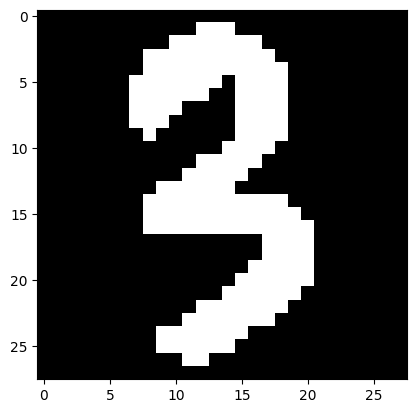

In [ ]:
import matplotlib.pyplot as plt

image_to_show = image_tensor.squeeze()

print(image_to_show.shape)
plt.imshow(image_to_show, cmap = 'gray')